# Feature Inspection And Subgraphs

This notebook is a small companion to the vectorization notebook. The question here is not how to build features, but how to inspect what those hashed interpretation-node labels correspond to in terms of actual base subgraphs.


Previous: [08 Preprocessor Attention Pipeline](./example_abstract_graph_operators_08_preprocessor_attention_pipeline.ipynb)

This notebook is intentionally short. It focuses on the inspection helpers in `abstractgraph.feature_subgraphs`.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import pandas as pd
import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style>')


In [3]:
from abstractgraph.operators import *
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display_graph
from abstractgraph.feature_subgraphs import feature_subgraphs, display_feature_subgraphs


def make_graph(extra_triangle=False, branch=False):
    graph = nx.Graph()
    graph.add_nodes_from([
        (0, {'label': 'C'}),
        (1, {'label': 'C'}),
        (2, {'label': 'O'}),
        (3, {'label': 'N'}),
        (4, {'label': 'C'}),
        (5, {'label': 'S'}),
        (6, {'label': 'C'}),
        (7, {'label': 'O'}),
    ])
    graph.add_edges_from([
        (0, 1, {'label': 'ring'}),
        (1, 2, {'label': 'ring'}),
        (2, 3, {'label': 'ring'}),
        (3, 0, {'label': 'ring'}),
        (2, 4, {'label': 'bridge'}),
        (4, 5, {'label': 'ring'}),
        (5, 2, {'label': 'ring'}),
        (3, 6, {'label': 'branch'}),
        (6, 7, {'label': 'branch'}),
    ])
    if extra_triangle:
        graph.add_node(8, label='C')
        graph.add_node(9, label='N')
        graph.add_edges_from([
            (1, 8, {'label': 'ring'}),
            (8, 9, {'label': 'ring'}),
            (9, 1, {'label': 'ring'}),
        ])
    if branch:
        graph.add_node(8, label='Cl')
        graph.add_edge(5, 8, label='branch')
    return graph


## A tiny corpus of related graphs

We use three closely related graphs so that some abstract subgraphs recur across the corpus and some appear only in one variant.


graph_0: Graph with 8 nodes and 9 edges


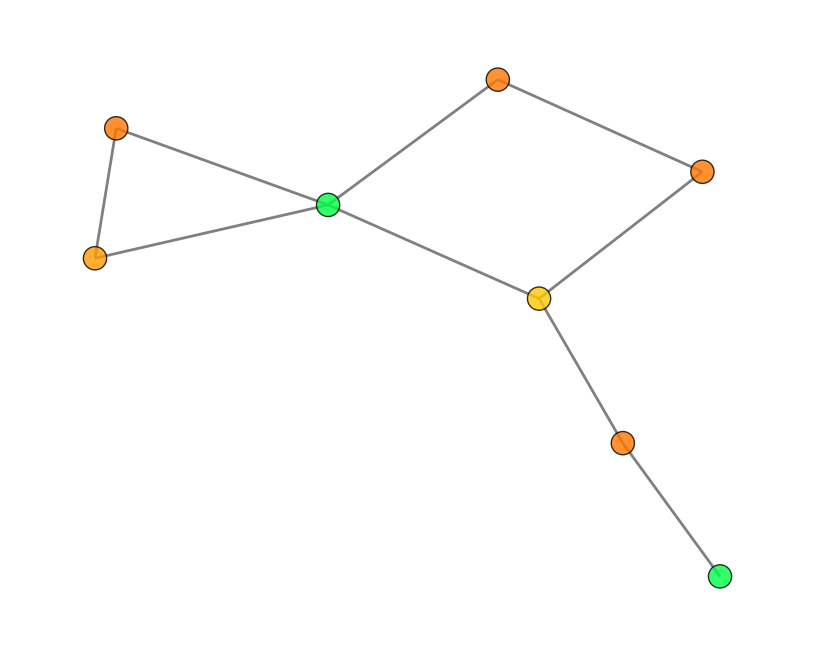

graph_1: Graph with 10 nodes and 12 edges


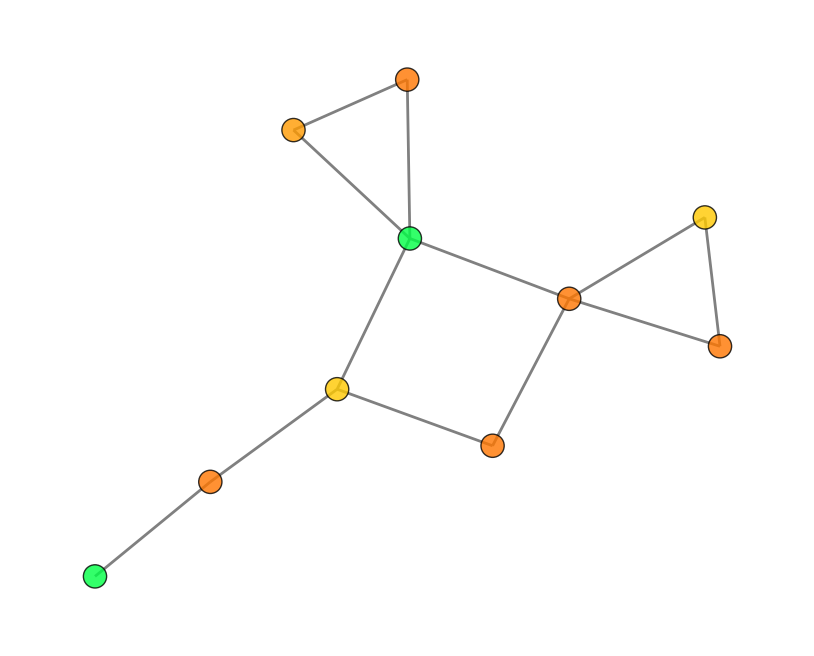

graph_2: Graph with 9 nodes and 10 edges


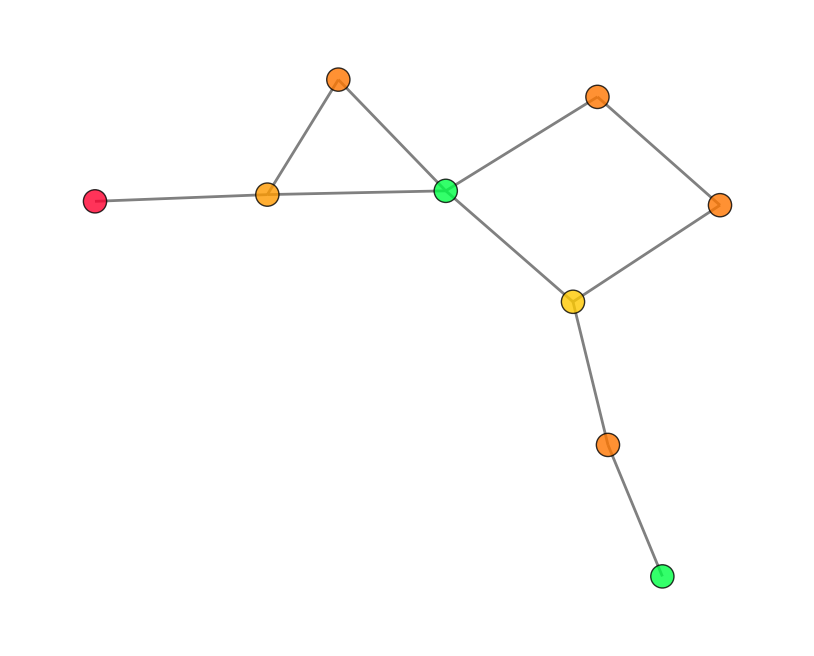

In [4]:
graphs = [
    make_graph(),
    make_graph(extra_triangle=True),
    make_graph(branch=True),
]

for i, graph in enumerate(graphs):
    print(f'graph_{i}:', graph)
    display_graph(graph)


## Choose a decomposition vocabulary

Feature inspection only makes sense relative to a decomposition. We start with cycles because they are visually easy to distinguish.


In [5]:
cycle_df = compose(cycle())
cycle_label_map = feature_subgraphs(graphs, decomposition_function=cycle_df, nbits=8)
print('number of feature labels:', len(cycle_label_map))
pd.Series({label: len(subgraphs) for label, subgraphs in cycle_label_map.items()}).sort_index()


number of feature labels: 3


25     1
134    1
192    1
dtype: int64

## What the labels point to

Each interpretation-node label bucket maps to one or more unique base subgraphs. The helper below renders those representative subgraphs grouped by label.


3 unique labels for 3 subgraphs.


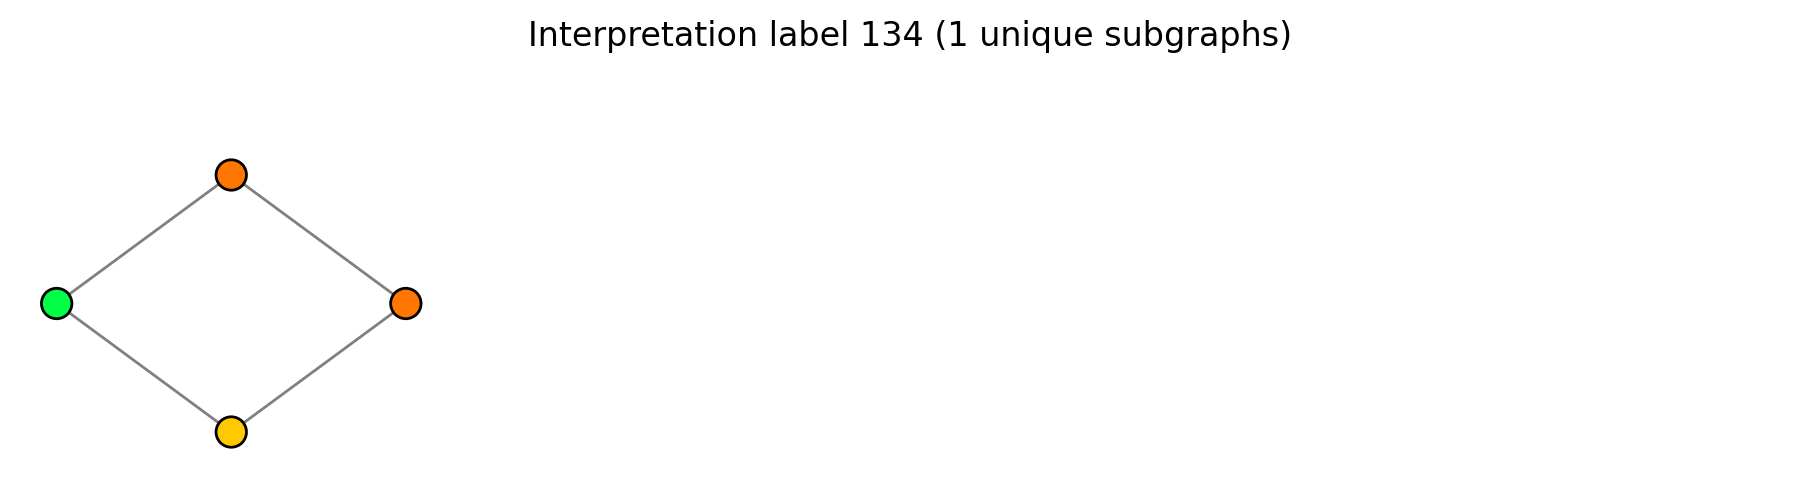

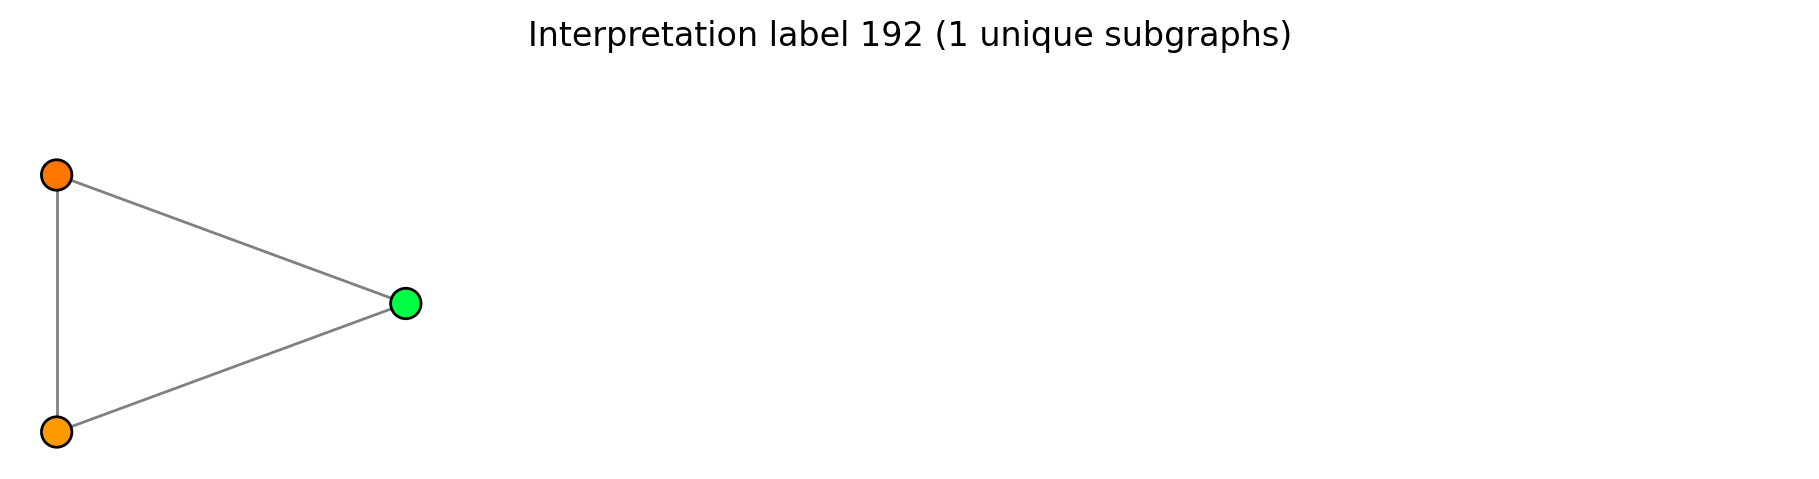

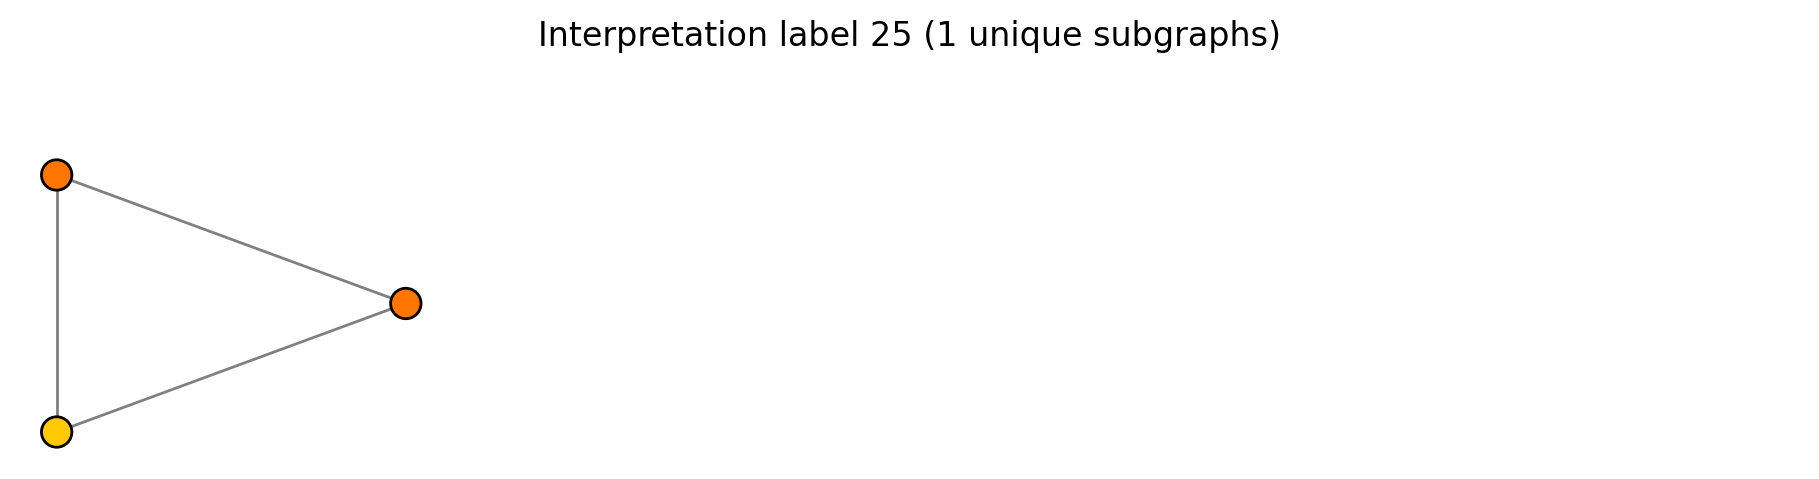

In [6]:
display_feature_subgraphs(graphs, decomposition_function=cycle_df, nbits=8, n_cols=4)


## Inspect a richer vocabulary

Now combine cycles with radius-1 neighborhoods. This produces more labels and shows how the feature vocabulary grows with the decomposition program.


In [7]:
mixed_df = compose(add(cycle(), neighborhood(radius=1)))
mixed_label_map = feature_subgraphs(graphs, decomposition_function=mixed_df, nbits=8)
summary_df = pd.DataFrame([
    {'label': label, 'n_unique_subgraphs': len(subgraphs)}
    for label, subgraphs in mixed_label_map.items()
]).sort_values(['n_unique_subgraphs', 'label'], ascending=[False, True])
summary_df.head(10)


,label,n_unique_subgraphs
7,25,2
4,44,2
5,35,1
6,76,1
8,81,1
9,117,1
1,134,1
0,192,1
2,243,1
3,253,1


## Compare labels to actual `AbstractGraph` interpretation nodes

The same label ids appear on interpretation nodes inside each decomposed graph. This makes the connection between numeric feature buckets and concrete subgraph instances explicit.


In [8]:
ag = graph_to_abstract_graph(graphs[1], decomposition_function=mixed_df, nbits=8)
rows = []
for node_id, data in ag.interpretation_graph.nodes(data=True):
    rows.append({
        'image_node': node_id,
        'label': data.get('label'),
        'n_base_nodes': data['mapped_subgraph'].number_of_nodes(),
        'n_base_edges': data['mapped_subgraph'].number_of_edges(),
    })
pd.DataFrame(rows).sort_values(['label', 'image_node']).head(12)


,image_node,label,n_base_nodes,n_base_edges
0,0,25,3,3
8,8,25,2,1
6,6,35,4,3
4,4,44,5,5
5,5,44,5,5
7,7,76,3,2
2,2,134,4,4
1,1,192,3,3
3,3,243,3,2


## Practical reading

This inspection workflow is useful when you want to answer questions like:

- which hashed labels are actually recurring across my dataset?
- which structural motifs dominate a given decomposition?
- when two graphs share a feature id, what subgraph shapes are behind that shared label?


## Summary

`feature_subgraphs(...)` and `display_feature_subgraphs(...)` are the shortest route from abstract hashed labels back to human-inspectable subgraph structure. They are especially useful after notebook 07, when you want to understand what the vectorizer is counting instead of treating feature ids as opaque.

Previous: [08 Preprocessor Attention Pipeline](./example_abstract_graph_operators_08_preprocessor_attention_pipeline.ipynb)
